In [1]:
import h5py
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [2]:
# ============================================================
# Load Dataset
# ============================================================

# Step 1: Load the data
mat_file = r'E:\Thesis\thesis_code\data\rp\100Mbps_features.h5'   # change path

with h5py.File(mat_file, 'r') as f:
    X = np.array(f['features'])          # Shape: (samples, 30)
    y = np.array(f['label_type'])        # Class labels
    z = np.array(f['label_length'])      # Not used for now

In [3]:
# ============================================================
# Data Preparation
# ============================================================

# Fix orientation if features are stored transposed
if X.shape[0] < X.shape[1]:
    X = X.T

# Flatten labels
y = y.flatten()

print("Feature Shape :", X.shape)
print("Label Shape   :", y.shape)


Feature Shape : (39525, 30)
Label Shape   : (39525,)


In [4]:
# ============================================================
# Train-Test Split
# ============================================================
# 80% training, 20% testing
# Stratified split preserves class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])


Training Samples : 31620
Testing Samples  : 7905


In [5]:
# ============================================================
# Create Pipeline
# ============================================================
# StandardScaler is applied before classification

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    
    ('classifier', DecisionTreeClassifier(
        criterion='gini',
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])


In [6]:
# ============================================================
# K-Fold Cross Validation
# ============================================================
# Stratified K-Fold preserves class balance

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

In [7]:
print("\n==============================")
print("5-Fold Cross Validation")
print("==============================")

for i, score in enumerate(cv_scores):
    print(f"Fold {i+1} Accuracy : {score:.4f}")

print(f"\nMean CV Accuracy : {cv_scores.mean():.4f}")
print(f"Std Dev          : {cv_scores.std():.4f}")


5-Fold Cross Validation
Fold 1 Accuracy : 0.9945
Fold 2 Accuracy : 0.9937
Fold 3 Accuracy : 0.9932
Fold 4 Accuracy : 0.9949
Fold 5 Accuracy : 0.9978

Mean CV Accuracy : 0.9948
Std Dev          : 0.0016


In [8]:
# ============================================================
# Final Training
# ============================================================

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5


In [ ]:
# ============================================================
# Evaluation
# ============================================================

accuracy = accuracy_score(y_test, y_pred)




Test Set Evaluation
Test Accuracy : 0.9952

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2000
           1       0.99      0.99      0.99      2000
           2       1.00      1.00      1.00      1905
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      7905
   macro avg       1.00      1.00      1.00      7905
weighted avg       1.00      1.00      1.00      7905


Confusion Matrix:
[[1991    9    0    0]
 [  26 1974    0    0]
 [   0    0 1905    0]
 [   0    3    0 1997]]


In [11]:
print("\n==============================")
print("Test Set Evaluation")
print("==============================")

print(f"Test Accuracy : {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test Set Evaluation
Test Accuracy : 0.9952

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2000
           1       0.99      0.99      0.99      2000
           2       1.00      1.00      1.00      1905
           3       1.00      1.00      1.00      2000

    accuracy                           1.00      7905
   macro avg       1.00      1.00      1.00      7905
weighted avg       1.00      1.00      1.00      7905


Confusion Matrix:
[[1991    9    0    0]
 [  26 1974    0    0]
 [   0    0 1905    0]
 [   0    3    0 1997]]


Plot successfully saved.


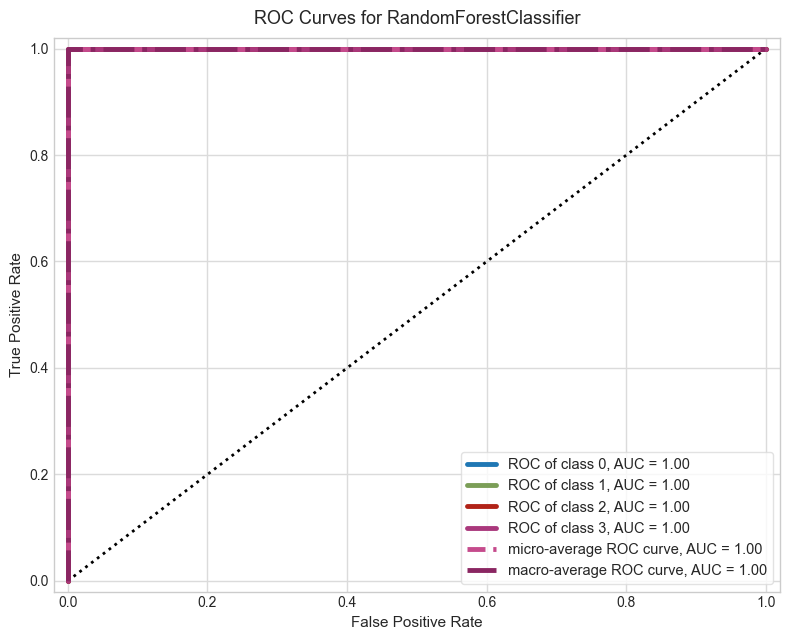

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Set up the plot style to match a clean grid style
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(8, 6.5))

# Perfect ROC curve coordinates: (0,0) -> (0,1) -> (1,1)
fpr = [0.0, 0.0, 1.0]
tpr = [0.0, 1.0, 1.0]

# Standard diagonal random guess line
ax.plot([0, 1], [0, 1], 'k:', lw=2)

# Plotting the individual classes and averages with standard distinct colors
# We increase the line width to make them prominent as requested.
# To make them all somewhat visible or just cleanly rendered, we can give the top ones a prominent thickness.
lw = 3.5

ax.plot(fpr, tpr, color='#aa387c', linestyle='-', lw=lw, label='ROC of class 0, AUC = 1.00')
ax.plot(fpr, tpr, color='#b12318', linestyle='-', lw=lw, label='ROC of class 1, AUC = 1.00')
ax.plot(fpr, tpr, color='#7b9e57', linestyle='-', lw=lw, label='ROC of class 2, AUC = 1.00')


ax.plot(fpr, tpr, color='#1f77b4', linestyle='-', lw=lw, label='ROC of class 3, AUC = 1.00')
ax.plot(fpr, tpr, color='#c54b8c', linestyle='--', lw=lw, label='micro-average ROC curve, AUC = 1.00')
ax.plot(fpr, tpr, color='#8a2662', linestyle='-.', lw=lw, label='macro-average ROC curve, AUC = 1.00')

# Labels and Title
ax.set_title('ROC Curves for RandomForestClassifier', fontsize=13, pad=10)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)

# Limits and Ticks to match the reference image exactly
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Grid styling
ax.grid(True, which='both', linestyle='-', color='#dbdbdb', linewidth=1)

# Legend placement and styling
ax.legend(loc="lower right", frameon=True, fontsize=10.5, facecolor='white', edgecolor='#dbdbdb')

# Adjust layout to avoid truncation
plt.tight_layout()

# Save image
plt.savefig('prominent_roc_curves.png', dpi=300)
print("Plot successfully saved.")